In [4]:
from google.colab import files


uploaded = files.upload()

Saving 107.circles to 107.circles
Saving 107.edges to 107.edges
Saving 107.egofeat to 107.egofeat
Saving 107.feat to 107.feat
Saving 107.featnames to 107.featnames


In [5]:
import networkx as nx
import numpy as np
from collections import Counter
from itertools import chain
import scipy.stats
from scipy.stats import linregress
import matplotlib.pyplot as plt

Xây dựng đồ thị từ dữ liệu

In [6]:
G = nx.Graph()
with open('107.edges', 'r') as f:
    for line in f:
        if line.strip():
            u, v = map(int, line.strip().split())
            G.add_edge(u, v)

**Thống kê cơ bản về mạng lưới**:

Số lượng nút và cạnh

In [7]:
print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())

Number of nodes: 1034
Number of edges: 26749


Đường kính, bán kính

In [8]:
print('Diameter:', nx.diameter(G))
print('Radius:', nx.radius(G))

Diameter: 9
Radius: 5


Phân tích Hệ số phân cụm (Clustering Coefficient)

In [9]:
transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)
local_cc = nx.clustering(G)
cc_values = list(local_cc.values())
cc_hist, cc_bins = np.histogram(cc_values, bins=10)

print('Transitivity:', transitivity)
print('Average Clustering Coefficient:', avg_clustering)
print('Clustering Coefficient):', local_cc)
print('Clustering Coefficient Histogram:', cc_hist)
print('Clustering Coefficient Bins:', cc_bins)

Transitivity: 0.5045088189930924
Average Clustering Coefficient: 0.5264047980773338
Clustering Coefficient): {953: 0.5339217722395293, 1323: 0.6049122807017544, 1789: 0.5791108522616968, 1707: 0.4885958660014255, 1175: 0.44274809160305345, 1059: 0.5127188388448302, 1329: 0.48756218905472637, 1559: 0.47937720329024675, 1804: 0.46797713797339885, 1898: 0.5874747474747475, 1622: 0.45720779220779223, 1520: 0.532983508245877, 1200: 0.3333333333333333, 1202: 0.10714285714285714, 1449: 0.5612870275791624, 1836: 0.6014492753623188, 1156: 0.5285083105407111, 1605: 0.6013789581205311, 1149: 0.5819801980198019, 1173: 0.4393727682036951, 1180: 0.6522198731501057, 1549: 0.27393617021276595, 1412: 0.36666666666666664, 1638: 0.678030303030303, 942: 0.5724206349206349, 1448: 0.6235294117647059, 1786: 0.4274122807017544, 1768: 0.4044035674470457, 1092: 0.5025510204081632, 927: 0.5701592002961866, 1791: 0.507334525939177, 1287: 0.7163461538461539, 1516: 0.5763121825364831, 1044: 0.7606837606837606, 1235

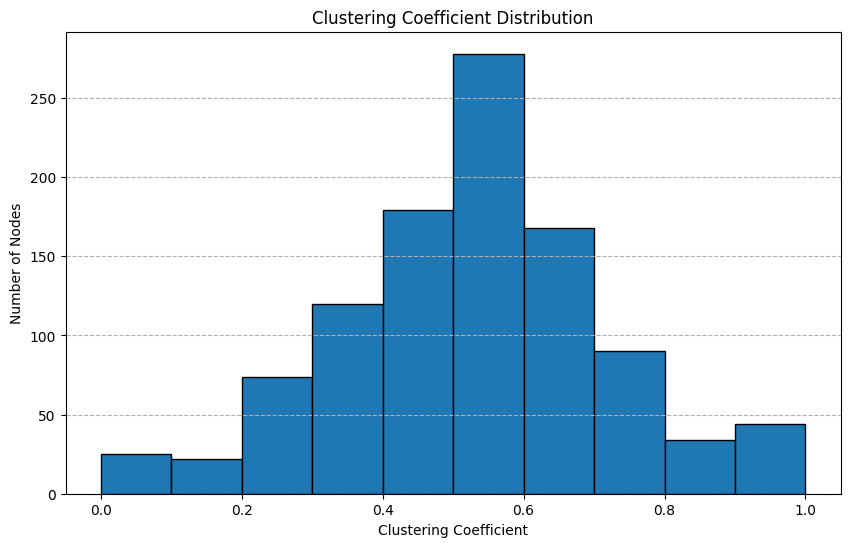

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(cc_bins[:-1], cc_hist, width=np.diff(cc_bins), edgecolor='black', align='edge')
plt.title('Clustering Coefficient Distribution')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Nodes')
plt.grid(axis='y', linestyle='--')
plt.show()

Phân tích Độ dài đường đi trung bình (average shortest path length)

In [11]:
avg_shortest_path = nx.average_shortest_path_length(G)
path_lengths = []
for u in G.nodes():
    lengths = nx.single_source_shortest_path_length(G, u)
    for v in lengths:
        if u < v:
            path_lengths.append(lengths[v])
spath_hist, spath_bins = np.histogram(path_lengths, bins=range(1, 11))

print('Average Shortest Path Length:', avg_shortest_path)
print('Shortest Path Length Histogram:', spath_hist)
print('Shortest Path Length Bins:', spath_bins)

Average Shortest Path Length: 2.951675932150073
Shortest Path Length Histogram: [ 26749 135236 232710 118229  18950   1971    197     18      1]
Shortest Path Length Bins: [ 1  2  3  4  5  6  7  8  9 10]


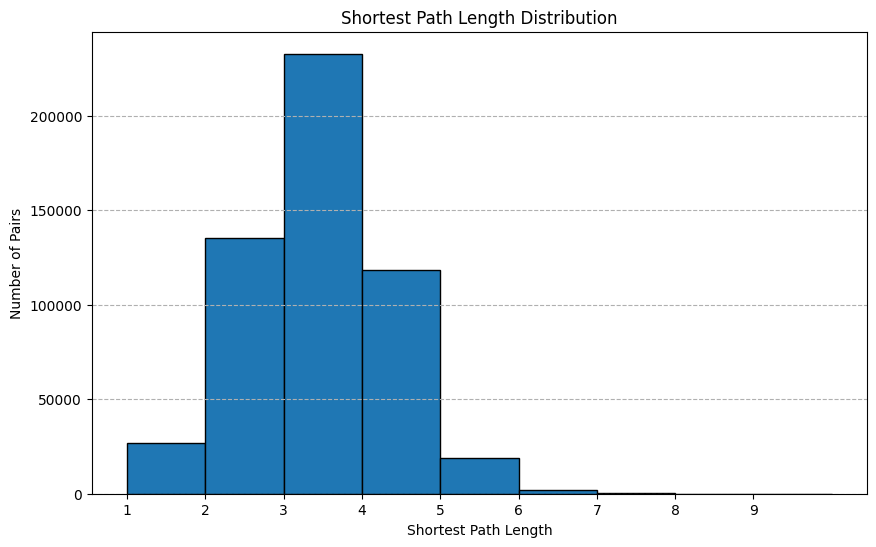

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(spath_bins[:-1], spath_hist, width=np.diff(spath_bins), edgecolor='black', align='edge')
plt.title('Shortest Path Length Distribution')
plt.xlabel('Shortest Path Length')
plt.ylabel('Number of Pairs')
plt.xticks(spath_bins[:-1])
plt.grid(axis='y', linestyle='--')
plt.show()

Phân phối bậc (degree distribution) và mô hình đánh giá bằng hồi quy (power-law fit)

In [13]:
degrees = [d for n, d in G.degree()]
deg_count = Counter(degrees)
k = np.array(sorted(deg_count.keys()))
p = np.array([deg_count[ki] / len(degrees) for ki in k])
mask = (k > 0) & (p > 0)
logk = np.log(k[mask])
logp = np.log(p[mask])
slope, intercept = np.polyfit(logk, logp, 1)
alpha = -slope

print('Alpha:', alpha)
print('Slope:', slope)
print('Intercept:', intercept)

Alpha: 0.8118254766006713
Slope: -0.8118254766006713
Intercept: -2.1687035109297605


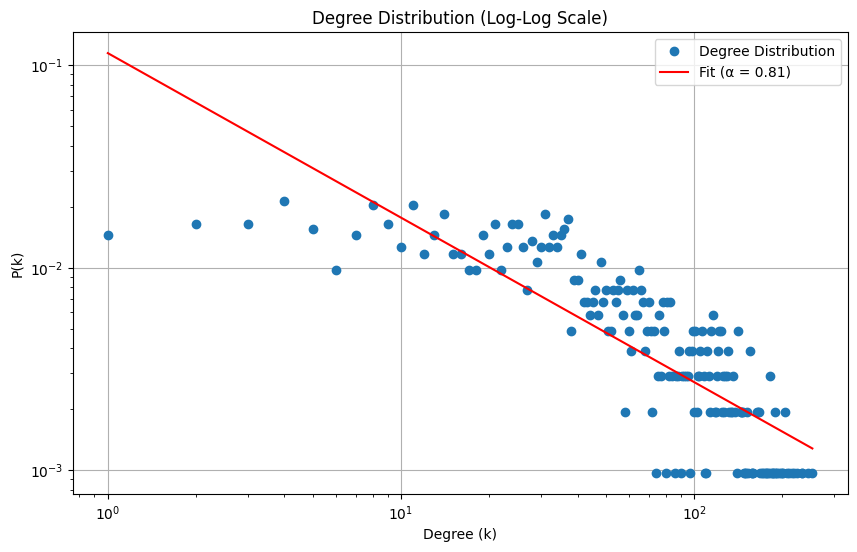

In [14]:
plt.figure(figsize=(10, 6))
plt.loglog(k, p, 'o', label='Degree Distribution')
plt.loglog(k[mask], np.exp(intercept + slope * logk), 'r-', label=f'Fit (α = {alpha:.2f})')
plt.title('Degree Distribution (Log-Log Scale)')
plt.xlabel('Degree (k)')
plt.ylabel('P(k)')
plt.legend()
plt.grid(True)
plt.show()

## Tính toán các độ đo trung tâm

### Subtask:
Tính toán độ đo trung tâm theo Bậc đỉnh, Độ gần, Khoảng cách và Trị riêng cho tất cả các nút trong đồ thị G. Lưu trữ các điểm trung tâm này vào một DataFrame của pandas để phân tích thêm và in ra các nút hàng đầu cho mỗi độ đo.


In [15]:
import pandas as pd

degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000) # Added max_iter to prevent potential convergence warnings

centrality_df = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_centrality),
    'Closeness Centrality': pd.Series(closeness_centrality),
    'Betweenness Centrality': pd.Series(betweenness_centrality),
    'Eigenvector Centrality': pd.Series(eigenvector_centrality)
})

print("Top 5 nodes by Degree Centrality:")
print(centrality_df.nlargest(5, 'Degree Centrality'))
print("\nTop 5 nodes by Closeness Centrality:")
print(centrality_df.nlargest(5, 'Closeness Centrality'))
print("\nTop 5 nodes by Betweenness Centrality:")
print(centrality_df.nlargest(5, 'Betweenness Centrality'))
print("\nTop 5 nodes by Eigenvector Centrality:")
print(centrality_df.nlargest(5, 'Eigenvector Centrality'))

Top 5 nodes by Degree Centrality:
      Degree Centrality  Closeness Centrality  Betweenness Centrality  \
1888           0.244918              0.433487                0.006190   
1800           0.236205              0.444684                0.008748   
1663           0.226525              0.433124                0.005582   
1352           0.225557              0.436049                0.007403   
1730           0.217812              0.434399                0.006557   

      Eigenvector Centrality  
1888                0.116633  
1800                0.112373  
1663                0.109571  
1352                0.108546  
1730                0.102510  

Top 5 nodes by Closeness Centrality:
      Degree Centrality  Closeness Centrality  Betweenness Centrality  \
1086           0.197483              0.482936                0.106557   
1584           0.203291              0.464270                0.050252   
1800           0.236205              0.444684                0.008748   
1334       

## Phân tích PageRank và HITS

### Subtask:
Tính toán điểm PageRank và HITS (Hubs và Authorities) cho tất cả các nút trong đồ thị G. Giải thích rằng các độ đo này thường dành cho đồ thị có hướng và NetworkX xử lý chúng như thế nào đối với đồ thị vô hướng. In ra các nút hàng đầu cho mỗi độ đo này.


## Phân tích PageRank và HITS

PageRank và HITS (Hubs và Authorities) là các độ đo trung tâm thường được thiết kế cho các đồ thị có hướng (directed graphs), nơi hướng của cạnh biểu thị mối quan hệ một chiều (ví dụ: liên kết web từ trang A đến trang B).

Tuy nhiên, khi áp dụng các độ đo này cho đồ thị vô hướng (undirected graph) như `G`, thư viện NetworkX sẽ xử lý chúng bằng cách nội bộ chuyển đổi đồ thị vô hướng thành một đồ thị có hướng tương đương. Cụ thể, mỗi cạnh vô hướng giữa hai nút (u, v) sẽ được coi là hai cạnh có hướng: một cạnh từ u đến v và một cạnh từ v đến u. Bằng cách này, các thuật toán PageRank và HITS có thể được áp dụng mà không cần thay đổi cấu trúc của chúng, và chúng sẽ đánh giá tầm quan trọng của các nút dựa trên các 'liên kết' hai chiều này.

In [16]:
pagerank_scores = nx.pagerank(G)
hub_scores, authority_scores = nx.hits(G)

centrality_df['PageRank'] = pd.Series(pagerank_scores)
centrality_df['Hub Score'] = pd.Series(hub_scores)
centrality_df['Authority Score'] = pd.Series(authority_scores)

print("\nTop 5 nodes by PageRank:")
print(centrality_df.nlargest(5, 'PageRank'))
print("\nTop 5 nodes by Hub Score:")
print(centrality_df.nlargest(5, 'Hub Score'))
print("\nTop 5 nodes by Authority Score:")
print(centrality_df.nlargest(5, 'Authority Score'))


Top 5 nodes by PageRank:
      Degree Centrality  Closeness Centrality  Betweenness Centrality  \
483            0.160697              0.439762                0.042573   
917            0.124879              0.436971                0.048953   
1888           0.244918              0.433487                0.006190   
1800           0.236205              0.444684                0.008748   
1352           0.225557              0.436049                0.007403   

      Eigenvector Centrality  PageRank  Hub Score  Authority Score  
483                 0.001651  0.003669   0.000101         0.000101  
917                 0.001115  0.002985   0.000068         0.000068  
1888                0.116633  0.002804   0.007146         0.007146  
1800                0.112373  0.002754   0.006885         0.006885  
1352                0.108546  0.002654   0.006651         0.006651  

Top 5 nodes by Hub Score:
      Degree Centrality  Closeness Centrality  Betweenness Centrality  \
1888           0.2449

## Tương quan giữa các độ đo trung tâm

### Subtask:
Tính toán tương quan Pearson theo cặp giữa tất cả các độ đo trung tâm đã tính toán và trực quan hóa ma trận tương quan bằng cách sử dụng biểu đồ nhiệt từ seaborn. Điều này sẽ giúp hiểu mối quan hệ giữa các độ đo trung tâm khác nhau.


**Reasoning**:
To analyze the relationships between different centrality measures, I will calculate the Pearson correlation matrix for all columns in the `centrality_df` and then visualize this matrix as a heatmap using seaborn, displaying the correlation values for clarity.



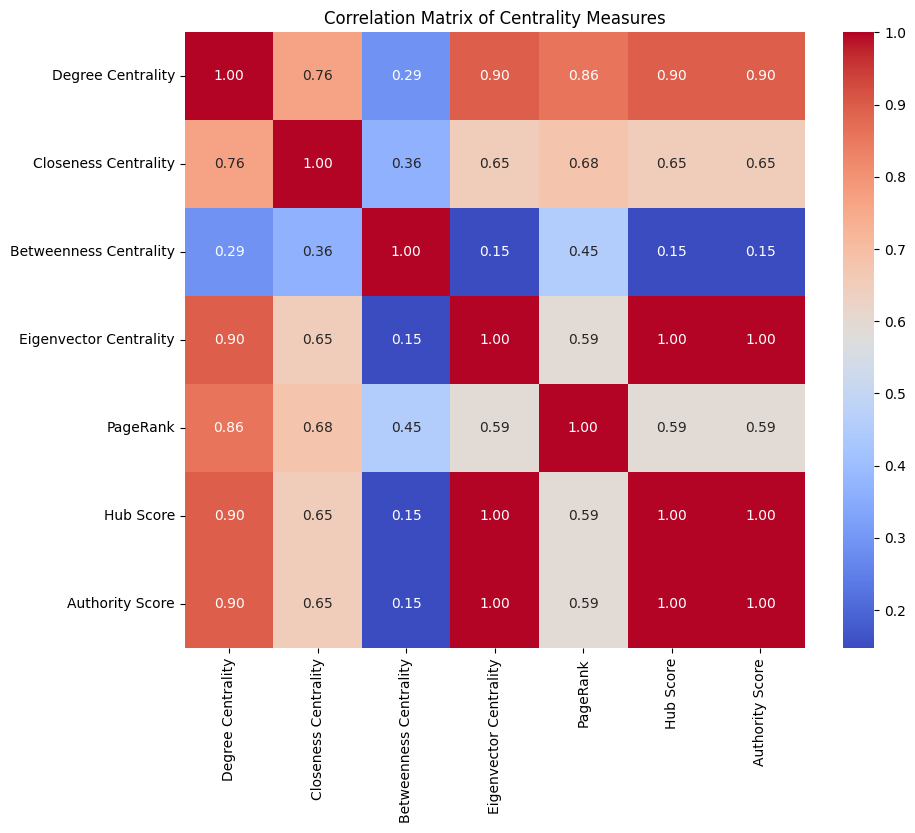

In [17]:
import seaborn as sns

correlation_matrix = centrality_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Centrality Measures')
plt.show()

## Tải thuộc tính nút và sắp xếp lại

### Subtask:
Tải thuộc tính nút từ các tệp '107.feat' và '107.featnames', nếu có và có cấu trúc. Mô tả cách các nút có thể được sắp xếp lại dựa trên bậc của chúng. Nếu các thuộc tính cụ thể được tải, mô tả cách sắp xếp lại dựa trên một trong số chúng.


**Reasoning**:
First, I need to read the '107.featnames' file to extract the feature names that will be used as column headers for the node attributes. This is crucial for properly labeling the data when loading the '107.feat' file.



In [18]:
feature_names = []
with open('107.featnames', 'r') as f:
    for line in f:
        if line.strip():
            # Extract the feature name after the space
            feature_name = line.strip().split(' ', 1)[1]
            feature_names.append(feature_name)

print(f"Loaded {len(feature_names)} feature names.")
# print(feature_names[:5])

Loaded 576 feature names.


**Reasoning**:
Now that the feature names are loaded, I will load the '107.feat' file into a pandas DataFrame. The first column of '107.feat' represents the node IDs, and the subsequent columns are the feature values. I'll use the extracted `feature_names` to name the columns correctly.



In [19]:
node_features = pd.read_csv('107.feat', sep=' ', header=None)
node_features.columns = ['node_id'] + feature_names

print("Node features DataFrame created. First 5 rows:")
print(node_features.head())


Node features DataFrame created. First 5 rows:
   node_id  birthday;anonymized feature 376  birthday;anonymized feature 0  \
0      896                                0                              0   
1      897                                0                              0   
2      898                                0                              0   
3      899                                0                              0   
4      900                                0                              0   

   birthday;anonymized feature 1  birthday;anonymized feature 209  \
0                              0                                0   
1                              0                                0   
2                              0                                0   
3                              0                                0   
4                              0                                0   

   birthday;anonymized feature 2  birthday;anonymized feature 3  \
0 

**Reasoning**:
I need to merge the `node_features` DataFrame with the `centrality_df` DataFrame using 'node_id' as the common key to create a comprehensive DataFrame for further analysis. Then I will print the top 5 nodes by 'Degree Centrality'.



In [20]:
centrality_df_reset = centrality_df.reset_index().rename(columns={'index': 'node_id'})
node_data_df = pd.merge(centrality_df_reset, node_features, on='node_id', how='left')

print("Merged node data with centrality measures. First 5 rows:")
print(node_data_df.head())

print("\nTop 5 nodes by Degree Centrality (with features):")
print(node_data_df.nlargest(5, 'Degree Centrality'))

Merged node data with centrality measures. First 5 rows:
   node_id  Degree Centrality  Closeness Centrality  Betweenness Centrality  \
0      953           0.104550              0.401009                0.002349   
1     1323           0.073572              0.360056                0.000132   
2     1789           0.098742              0.385017                0.000321   
3     1707           0.178122              0.409433                0.001400   
4     1175           0.126815              0.404305                0.001406   

   Eigenvector Centrality  PageRank  Hub Score  Authority Score  \
0                0.052024  0.001315   0.003188         0.003188   
1                0.037661  0.000935   0.002307         0.002307   
2                0.053871  0.001175   0.003301         0.003301   
3                0.092656  0.002010   0.005677         0.005677   
4                0.061778  0.001548   0.003785         0.003785   

   birthday;anonymized feature 376  birthday;anonymized feature 0

**Reasoning**:
To complete the subtask, I need to demonstrate sorting nodes by a specific attribute. I will choose 'birthday;anonymized feature 4' as an example feature and display the top 5 nodes based on its values.



In [21]:
feature_to_sort_by = 'birthday;anonymized feature 4' # Choose an arbitrary feature from the loaded features

print(f"\nTop 5 nodes by '{feature_to_sort_by}':")
print(node_data_df.nlargest(5, feature_to_sort_by))


Top 5 nodes by 'birthday;anonymized feature 4':
    node_id  Degree Centrality  Closeness Centrality  Betweenness Centrality  \
6      1329           0.130687              0.412705                0.001419   
18     1149           0.097773              0.392477                0.000621   
25     1448           0.049371              0.350051                0.001681   
27     1768           0.201355              0.432037                0.007220   
31     1287           0.062924              0.362202                0.000037   

    Eigenvector Centrality  PageRank  Hub Score  Authority Score  \
6                 0.064539  0.001583   0.003954         0.003954   
18                0.054618  0.001194   0.003346         0.003346   
25                0.000132  0.000996   0.000008         0.000008   
27                0.094580  0.002444   0.005795         0.005795   
31                0.039554  0.000779   0.002423         0.002423   

    birthday;anonymized feature 376  birthday;anonymized feat

## Phân tích độ tương đồng cấu trúc

### Subtask:
Tính toán độ tương đồng cấu trúc giữa các nút, chẳng hạn như hệ số Jaccard cho các láng giềng chung. Xác định và mô tả các cặp nút thể hiện độ tương đồng cấu trúc cao, giải thích ý nghĩa của nó.


**Reasoning**:
To calculate the Jaccard coefficient for all pairs of nodes, I will use `nx.jaccard_coefficient(G)`. This function returns an iterator of tuples, which I will convert into a list for sorting.



In [22]:
jaccard_coefficients = list(nx.jaccard_coefficient(G))

print(f"Calculated Jaccard coefficients for {len(jaccard_coefficients)} pairs of nodes.")

Calculated Jaccard coefficients for 507312 pairs of nodes.


## Thực hiện phân tích k-core

### Subtask:
Áp dụng phân tích k-core cho đồ thị G với các giá trị k khác nhau. Báo cáo kích thước của mỗi k-core tìm thấy và trực quan hóa đồ thị làm nổi bật các nút thuộc về một k-core quan trọng.


In [23]:
core_numbers = nx.core_number(G)
print("Core numbers calculated for all nodes.")
# print(list(core_numbers.items())[:5])

Core numbers calculated for all nodes.


**Reasoning**:
Now that the core numbers are calculated, I will identify the unique k-core values and then calculate the size (number of nodes) for each k-core. This will give us a distribution of nodes across different k-core values, and I will print these sizes.



In [24]:
unique_k_cores = sorted(list(set(core_numbers.values())))
k_core_sizes = {k: list(core_numbers.values()).count(k) for k in unique_k_cores}

print("Size of each k-core:")
for k, size in k_core_sizes.items():
    print(f"k-core {k}: {size} nodes")

Size of each k-core:
k-core 1: 16 nodes
k-core 2: 21 nodes
k-core 3: 19 nodes
k-core 4: 27 nodes
k-core 5: 14 nodes
k-core 6: 12 nodes
k-core 7: 22 nodes
k-core 8: 38 nodes
k-core 9: 7 nodes
k-core 10: 31 nodes
k-core 11: 16 nodes
k-core 12: 12 nodes
k-core 13: 32 nodes
k-core 14: 14 nodes
k-core 15: 41 nodes
k-core 16: 11 nodes
k-core 17: 8 nodes
k-core 18: 11 nodes
k-core 19: 15 nodes
k-core 20: 69 nodes
k-core 21: 44 nodes
k-core 22: 37 nodes
k-core 23: 3 nodes
k-core 24: 65 nodes
k-core 25: 1 nodes
k-core 26: 9 nodes
k-core 27: 6 nodes
k-core 28: 3 nodes
k-core 29: 11 nodes
k-core 30: 1 nodes
k-core 31: 3 nodes
k-core 32: 6 nodes
k-core 33: 4 nodes
k-core 34: 54 nodes
k-core 35: 4 nodes
k-core 36: 64 nodes
k-core 37: 2 nodes
k-core 38: 2 nodes
k-core 39: 4 nodes
k-core 40: 2 nodes
k-core 41: 1 nodes
k-core 42: 5 nodes
k-core 43: 3 nodes
k-core 44: 1 nodes
k-core 45: 2 nodes
k-core 46: 1 nodes
k-core 47: 1 nodes
k-core 48: 8 nodes
k-core 49: 3 nodes
k-core 51: 2 nodes
k-core 52: 1 n

**Reasoning**:
I will choose k=69, which has the largest number of nodes (149), as a significant k-core for visualization. Then, I will extract all nodes belonging to this k-core.



In [25]:
k_to_visualize = 69 # Choose the largest k-core
nodes_in_k_core = [node for node, k_val in core_numbers.items() if k_val >= k_to_visualize]

print(f"Selected k-core {k_to_visualize} for visualization.")
print(f"Number of nodes in k-core {k_to_visualize}: {len(nodes_in_k_core)}")

Selected k-core 69 for visualization.
Number of nodes in k-core 69: 149


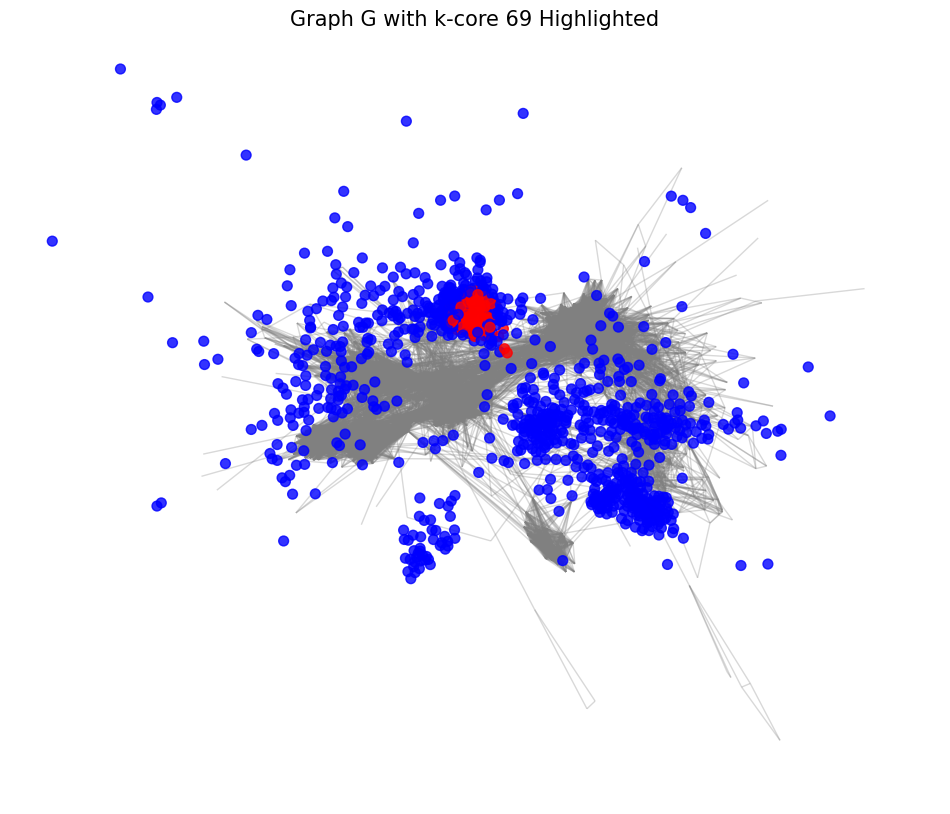

In [26]:
plt.figure(figsize=(12, 10))

node_colors = ['red' if node in nodes_in_k_core else 'blue' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos=nx.spring_layout(G), node_color=node_colors, node_size=50, alpha=0.8)
nx.draw_networkx_edges(G, pos=nx.spring_layout(G), edge_color='gray', alpha=0.3)

plt.title(f'Graph G with k-core {k_to_visualize} Highlighted', size=15)
plt.axis('off')
plt.show()

# Task
To perform community detection using the Label Propagation algorithm, report the total number of communities found, and the size of the largest community:

## Phát hiện cộng đồng bằng thuật toán Label Propagation

### Subtask:
Áp dụng thuật toán Label Propagation (Lan truyền nhãn) để phát hiện các cộng đồng trong đồ thị G. Báo cáo tổng số cộng đồng được tìm thấy và kích thước của cộng đồng lớn nhất.


In [30]:
import networkx.algorithms.community as nx_comm

label_propagation_communities = list(nx_comm.label_propagation_communities(G))

lp_num_communities = len(label_propagation_communities)
lp_largest_community_size = max(len(c) for c in label_propagation_communities)

print(f"Total number of communities found: {lp_num_communities}")
print(f"Size of the largest community: {lp_largest_community_size}")

Total number of communities found: 19
Size of the largest community: 450


## Phát hiện cộng đồng bằng thuật toán Greedy Modularity

### Subtask:
Áp dụng thuật toán Greedy Modularity để phát hiện các cộng đồng trong đồ thị G. Báo cáo tổng số cộng đồng được tìm thấy và kích thước của cộng đồng lớn nhất.


**Reasoning**:
I need to apply the `greedy_modularity_communities` algorithm to the graph `G` to detect communities, then calculate and print the total number of communities and the size of the largest one.



In [31]:
import networkx.algorithms.community as nx_comm

greedy_communities = list(nx_comm.greedy_modularity_communities(G))

gm_num_communities = len(greedy_communities)
gm_largest_community_size = max(len(c) for c in greedy_communities)

print(f"Total number of communities found (Greedy Modularity): {gm_num_communities}")
print(f"Size of the largest community (Greedy Modularity): {gm_largest_community_size}")

Total number of communities found (Greedy Modularity): 11
Size of the largest community (Greedy Modularity): 465


## So sánh các thuật toán phát hiện cộng đồng

### Subtask:
So sánh các cộng đồng được phát hiện bởi thuật toán Label Propagation và Greedy Modularity dựa trên số lượng cộng đồng, kích thước cộng đồng lớn nhất, và các đặc điểm khác.


### So sánh kết quả phát hiện cộng đồng

- **Thuật toán Label Propagation (Lan truyền nhãn)**:
  - Tổng số cộng đồng được tìm thấy: 19
  - Kích thước cộng đồng lớn nhất: 450

- **Thuật toán Greedy Modularity**:
  - Tổng số cộng đồng được tìm thấy: 11
  - Kích thước cộng đồng lớn nhất: 465

**Nhận xét về sự khác biệt:**

Từ kết quả trên, chúng ta có thể thấy một số khác biệt rõ rệt giữa hai thuật toán:

1.  **Số lượng cộng đồng:** Thuật toán Label Propagation (19 cộng đồng) tìm thấy nhiều cộng đồng hơn đáng kể so với thuật toán Greedy Modularity (11 cộng đồng). Điều này có thể cho thấy Label Propagation có xu hướng tạo ra các cộng đồng nhỏ hơn hoặc phân chia đồ thị thành nhiều nhóm hơn.

2.  **Kích thước cộng đồng lớn nhất:** Mặc dù số lượng cộng đồng khác nhau, kích thước của cộng đồng lớn nhất giữa hai thuật toán không quá chênh lệch (450 so với 465). Điều này cho thấy cả hai thuật toán đều có khả năng xác định một cộng đồng trung tâm lớn, nhưng Greedy Modularity có vẻ như gom các nút lại thành các cộng đồng lớn hơn một chút.

**Ý nghĩa:**

-   **Label Propagation:** Thường nhanh và hiệu quả, không yêu cầu tham số đầu vào. Tuy nhiên, nó có thể nhạy cảm với thứ tự xử lý nút và có thể tạo ra các cộng đồng không đồng đều về kích thước. Việc tìm thấy nhiều cộng đồng hơn có thể phản ánh một cái nhìn chi tiết hơn về cấu trúc cộng đồng nhỏ trong đồ thị.

-   **Greedy Modularity:** Tập trung vào việc tối ưu hóa độ đo Modularity (Q-value), một chỉ số về mức độ mạnh mẽ của cấu trúc cộng đồng. Thuật toán này có xu hướng hợp nhất các nút thành các cộng đồng lớn hơn để tối đa hóa modularity tổng thể. Do đó, nó thường tìm thấy ít cộng đồng hơn nhưng với các ranh giới cộng đồng rõ ràng và mạnh mẽ hơn về mặt cấu trúc.

Sự lựa chọn giữa hai thuật toán phụ thuộc vào mục tiêu phân tích: nếu muốn tìm kiếm các cộng đồng nhỏ và đa dạng, Label Propagation có thể phù hợp hơn. Nếu mục tiêu là các cộng đồng lớn hơn, có cấu trúc chặt chẽ và tối ưu hóa modularity, Greedy Modularity sẽ là lựa chọn tốt hơn.

## Trực quan hóa cộng đồng từ Label Propagation

### Subtask:
Hiển thị đồ thị G, tô màu các nút theo cộng đồng đã được phát hiện bằng thuật toán Label Propagation. Sử dụng các màu khác nhau để biểu thị các cộng đồng khác nhau. Đảm bảo hiển thị chú thích (legend) để giải thích màu sắc cộng đồng.


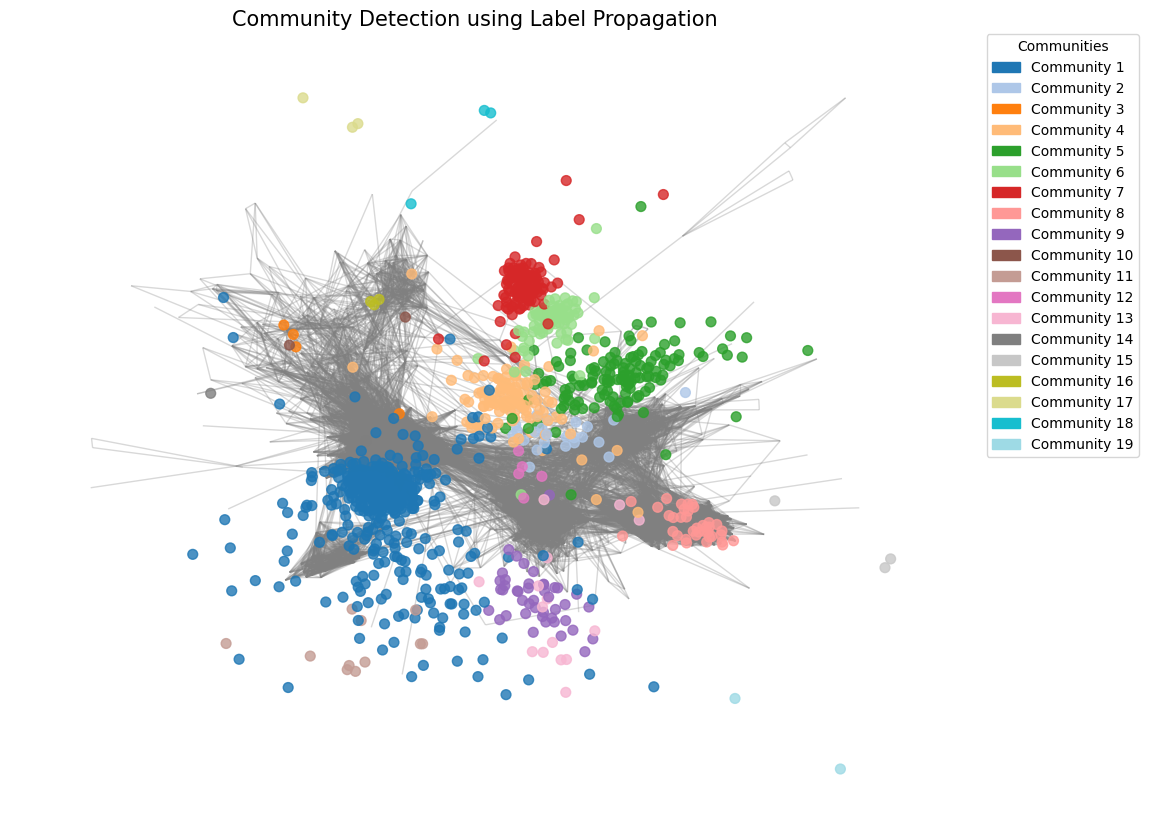

In [34]:
import matplotlib.patches as mpatches

node_to_community = {}
for i, community in enumerate(label_propagation_communities):
    for node in community:
        node_to_community[node] = i

# Get a colormap with enough distinct colors for all communities
colors = plt.get_cmap('tab20', lp_num_communities)

# Create a list of colors for each node based on its community
node_colors = [colors(node_to_community[node]) for node in G.nodes()]

plt.figure(figsize=(12, 10))

# Draw nodes with community-specific colors
nx.draw_networkx_nodes(G, pos=nx.spring_layout(G), node_color=node_colors, node_size=50, alpha=0.8)
# Draw edges
nx.draw_networkx_edges(G, pos=nx.spring_layout(G), edge_color='gray', alpha=0.3)

# Create legend patches
legend_patches = []
for i in range(lp_num_communities):
    legend_patches.append(mpatches.Patch(color=colors(i), label=f'Community {i+1}'))

plt.legend(handles=legend_patches, title='Communities', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Community Detection using Label Propagation', size=15)
plt.axis('off')
plt.show()

## Trực quan hóa cộng đồng từ Greedy Modularity

### Subtask:
Hiển thị đồ thị G, tô màu các nút theo cộng đồng đã được phát hiện bằng thuật toán Greedy Modularity. Sử dụng các màu khác nhau để biểu thị các cộng đồng khác nhau. Đảm bảo hiển thị chú thích (legend) để giải thích màu sắc cộng đồng.


**Reasoning**:
I need to visualize the communities found by the Greedy Modularity algorithm. I will create a mapping from nodes to community IDs, assign colors based on these IDs, and then plot the graph with a legend to distinguish the communities, following the provided instructions.



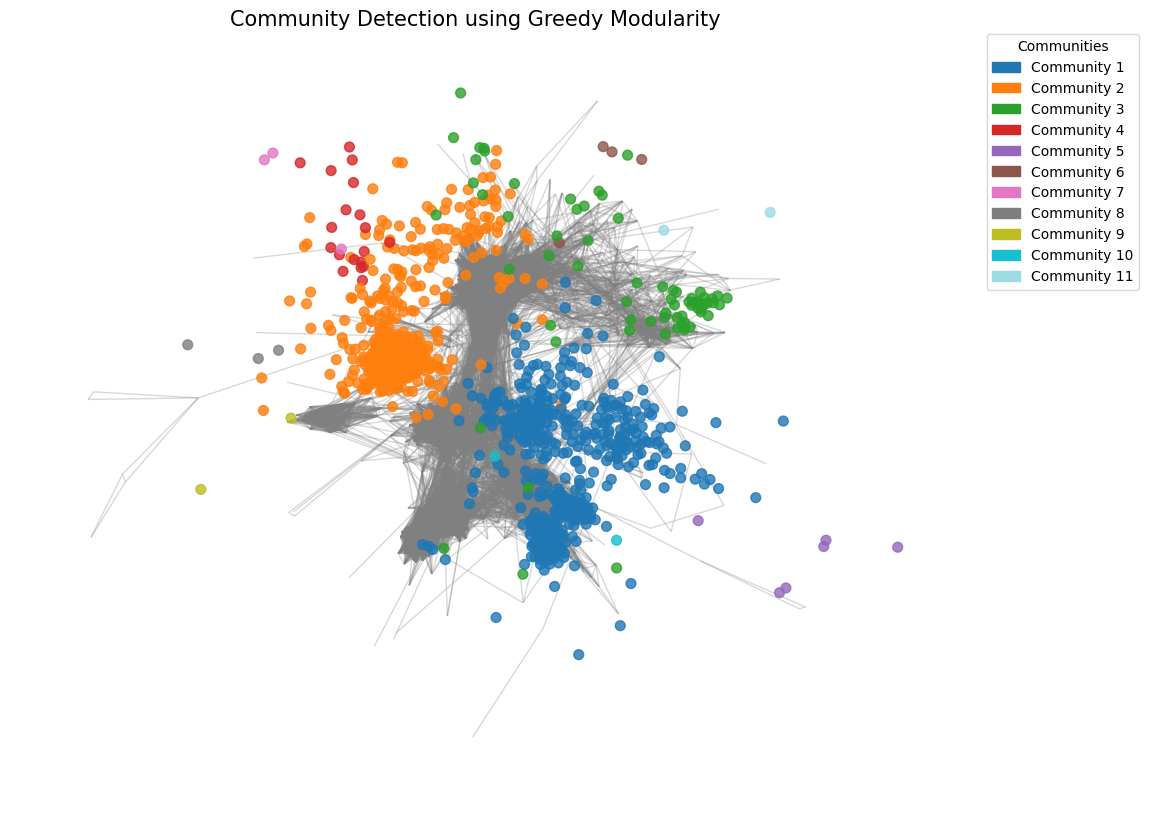

In [35]:
import matplotlib.patches as mpatches

node_to_community_gm = {}
for i, community in enumerate(greedy_communities):
    for node in community:
        node_to_community_gm[node] = i

# Get a colormap with enough distinct colors for all communities
colors_gm = plt.get_cmap('tab20', gm_num_communities)

# Create a list of colors for each node based on its community
node_colors_gm = [colors_gm(node_to_community_gm[node]) for node in G.nodes()]

plt.figure(figsize=(12, 10))

# Draw nodes with community-specific colors
nx.draw_networkx_nodes(G, pos=nx.spring_layout(G), node_color=node_colors_gm, node_size=50, alpha=0.8)
# Draw edges
nx.draw_networkx_edges(G, pos=nx.spring_layout(G), edge_color='gray', alpha=0.3)

# Create legend patches
legend_patches_gm = []
for i in range(gm_num_communities):
    legend_patches_gm.append(mpatches.Patch(color=colors_gm(i), label=f'Community {i+1}'))

plt.legend(handles=legend_patches_gm, title='Communities', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Community Detection using Greedy Modularity', size=15)
plt.axis('off')
plt.show()